 ### Haar Cascade
 It is an Object Detection Algorithm used to identify faces in an image or a real time video. The algorithm uses edge or line detection features proposed by Viola and Jones in their research paper “Rapid Object Detection using a Boosted Cascade of Simple Features” published in 2001. The algorithm is given a lot of positive images consisting of faces, and a lot of negative images not consisting of any face to train on them.

 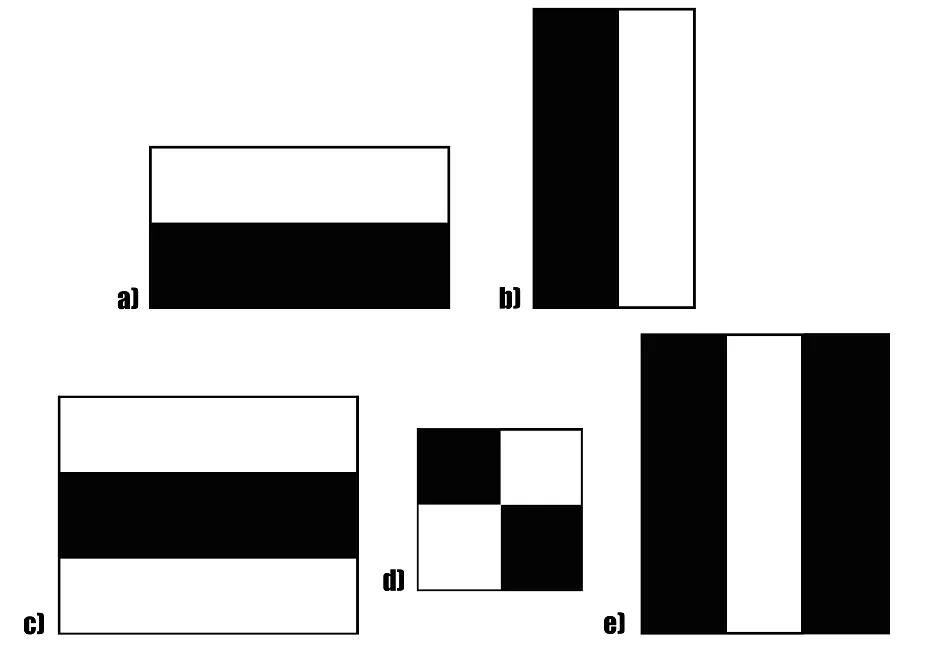

 The first contribution to the research was the introduction of the haar features shown above. These features on the image makes it easy to find out the edges or the lines in the image, or to pick areas where there is a sudden change in the intensities of the pixels.

 for more details : https://medium.com/data-science/face-detection-with-haar-cascade-727f68dafd08

In [1]:
import cv2

In [11]:
cam = cv2.VideoCapture(0)

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades+'haarcascade_frontalface_default.xml')

while True:
    ret,frame = cam.read()

    if not ret:
        print("Failed to grab frame")
        break
    gray = cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray,scaleFactor=1.3,minNeighbors=5)

    for (x,y,w,h) in faces:
        cv2.rectangle(frame,(x,y),(x+w,y+h),(255,0,0),2)

        cv2.putText(frame,"Face detected",(x,y-10),cv2.FONT_HERSHEY_SIMPLEX,0.9,(0,255,0),2,cv2.LINE_AA)

    cv2.imshow('camera',frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
    
cam.release()
cv2.destroyAllWindows()
                                  


In [22]:
cam = cv2.VideoCapture(0) 

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
mouth_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_smile.xml')
 
while True:
    ret, frame = cam.read()

    if not ret:
        print("Failed to grab frame")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

    for (x,y,w,h) in faces:
        cv2.rectangle(frame,(x,y),(x+w,y+h),(255,0,0),2)
        cv2.putText(frame,"Face detected",(x,y-10),cv2.FONT_HERSHEY_SIMPLEX,0.9,(0,255,0),2,cv2.LINE_AA)

        roi_gray = gray[y:y+h,x:x+w]
        roi_color = frame[y:y+h,x:x+w]

        eyes = eye_cascade.detectMultiScale(roi_gray,scaleFactor=1.3,minNeighbors=5)
        mouths = mouth_cascade.detectMultiScale(roi_gray,scaleFactor=1.8,minNeighbors=20)

        for (ex, ey, ew, eh) in eyes: 
            cv2.rectangle(frame, (x+ex, y+ey), (x +ex+ ew, y+ey + eh), (255, 0, 0), 2)
            cv2.putText(frame, "Eye", (x+ex, (y+ey) - 10),cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2, cv2.LINE_AA)

            
        for (mx, my, mw, mh) in mouths:
            cv2.rectangle(frame, (x+mx, y+my), (x +mx+ mw, y+my + mh), (255, 0, 0), 2)
            cv2.putText(frame, "Mouth", (x+mx, (y+my) - 10),cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2, cv2.LINE_AA)
            break


    cv2.imshow('camera', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cam.release()
cv2.destroyAllWindows()
